In [1]:
# add parent to path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import importlib

importlib.reload(importlib.import_module("wandb_utils"))

from wandb_utils import combine_histories, get_wandb_stats

# tpc-h bespoke storage linearge
run_ids = [
    "nhpul25g",  # plan storage
    "a2tlnfrk",  # basic impl
    "h1mv9o9r",  # optim
]


# run_id = "k9xst454"  # tpch - bespoke storage
# run_id = "ggikqms8"  # ceb
# run_id = "761bg8oe"  # ceb - bespoke storage

hists_list = []
for run_id in run_ids:
    summary, hist, config = get_wandb_stats(
        run_id,
        skip_cache=False,  # set to True to skip cache and fetch from W&B API
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )
    hists_list.append(hist)


combined_history = combine_histories(hists_list)

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/f813798a06f5f88ec7274e5087b4eefca156eb387a94fda7125264bafec6d3be.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/a88e90a90e889bfc1d66cfbd9ad3a7d47ac9133ece44f026d8deaf5502167226.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/a34a901d2f50cc51db2092712656d83dfe9b6d7757785b785003b489b84435c6.pkl
Combined history has 5672 rows ([7, 1001, 4664])


In [2]:
# skip nan
prompts = combined_history["current_prompt"].dropna()
prompts

0       Your task is to analyze the workload and produ...
7       You are an expert database engineer and skille...
14      finish all todos. Focus on the build logic to ...
55      Execute and check termination without error. F...
71      add time measurement for execution. Exclude th...
                              ...                        
5405    Your task is to optimize the existing codebase...
5410    Your task is to optimize the existing codebase...
5514    Your task is to optimize the existing codebase...
5571    Your task is to optimize the existing codebase...
5576    Your task is to optimize the existing codebase...
Name: current_prompt, Length: 150, dtype: str

Section 'storage' starts at index: 0.
Section 'implement queries' starts at index: 76.
Section 'pin & trace' starts at index: 1009.
Section 'optim card' starts at index: 1284.
Section 'optim trace' starts at index: 1754.
Section 'optim expert' starts at index: 3517.
Section 'optim human' starts at index: 4229.
Setting rows up to index 0 to 'storage'.
[WorkedOnSpan(start=0, end=75, queries='', section='storage', query_set=set()), WorkedOnSpan(start=76, end=116, queries='1', section='implement queries', query_set=set()), WorkedOnSpan(start=117, end=148, queries='2', section='implement queries', query_set=set()), WorkedOnSpan(start=149, end=173, queries='3', section='implement queries', query_set=set()), WorkedOnSpan(start=174, end=213, queries='4', section='implement queries', query_set=set()), WorkedOnSpan(start=214, end=250, queries='5', section='implement queries', query_set=set()), WorkedOnSpan(start=251, end=289, queries='6', section='implement queries', query_set=set()), WorkedOnSp

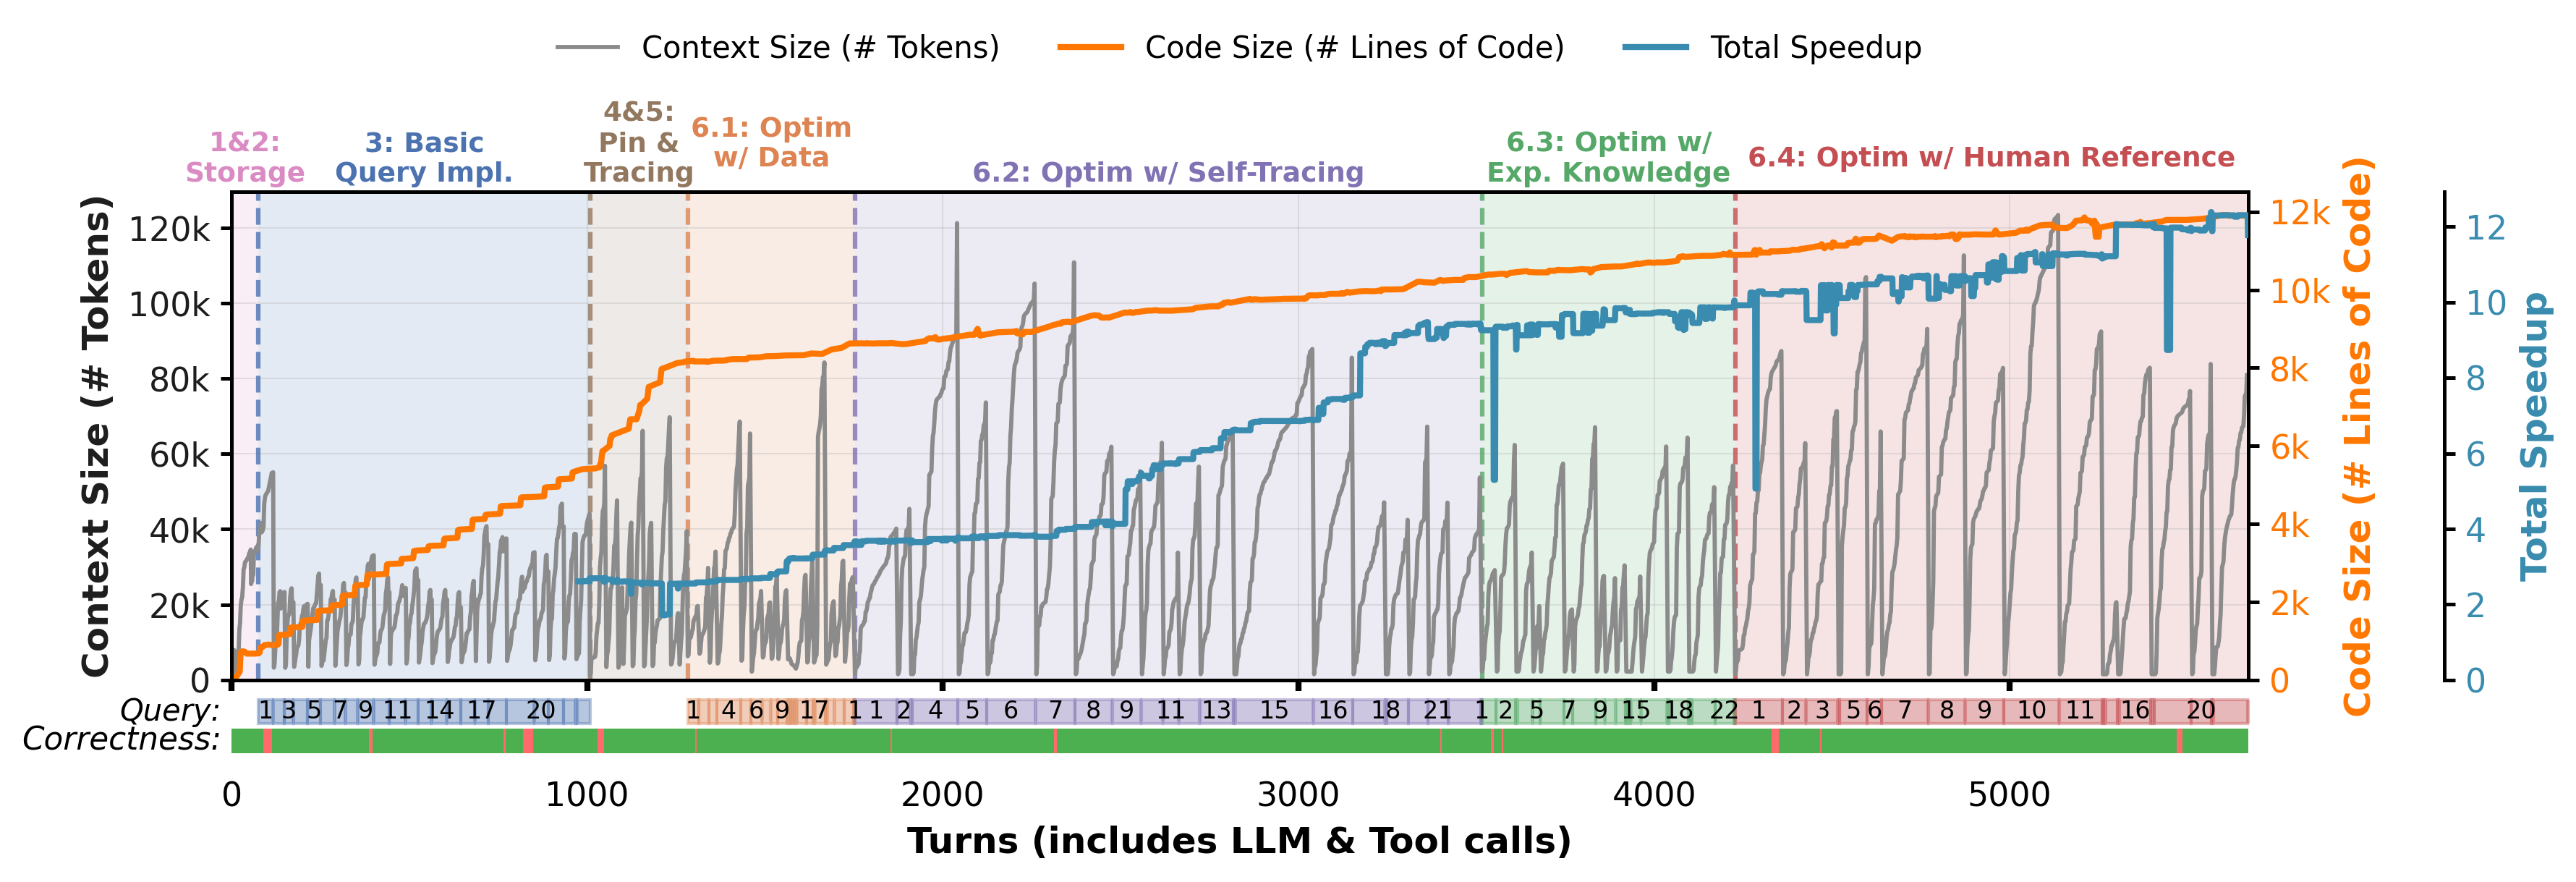

In [3]:
# add parent to path
import sys

from plots import wandb_trace_preprocessor

sys.path.append("..")

import importlib

importlib.reload(wandb_trace_preprocessor)
importlib.reload(importlib.import_module("plot_timeline"))

from plot_timeline import PlotConfig, TimelineEngine

engine = TimelineEngine(combined_history, summary, drill_down_to_query_level=True)


config = PlotConfig(
    left_axis_series=["input_tokens"],
    right_axis_series=["code_size"],
    right_axis2_series=["speedup"],
    highlight_correction_span=True,
    figsize=(12, 4),
    legend_y_offset=1.38,
)

fig, ax = engine.plot(config)


fig.tight_layout()
# save fig
fig.savefig("figures/timeline_plot.pdf", bbox_inches="tight", pad_inches=0.0)

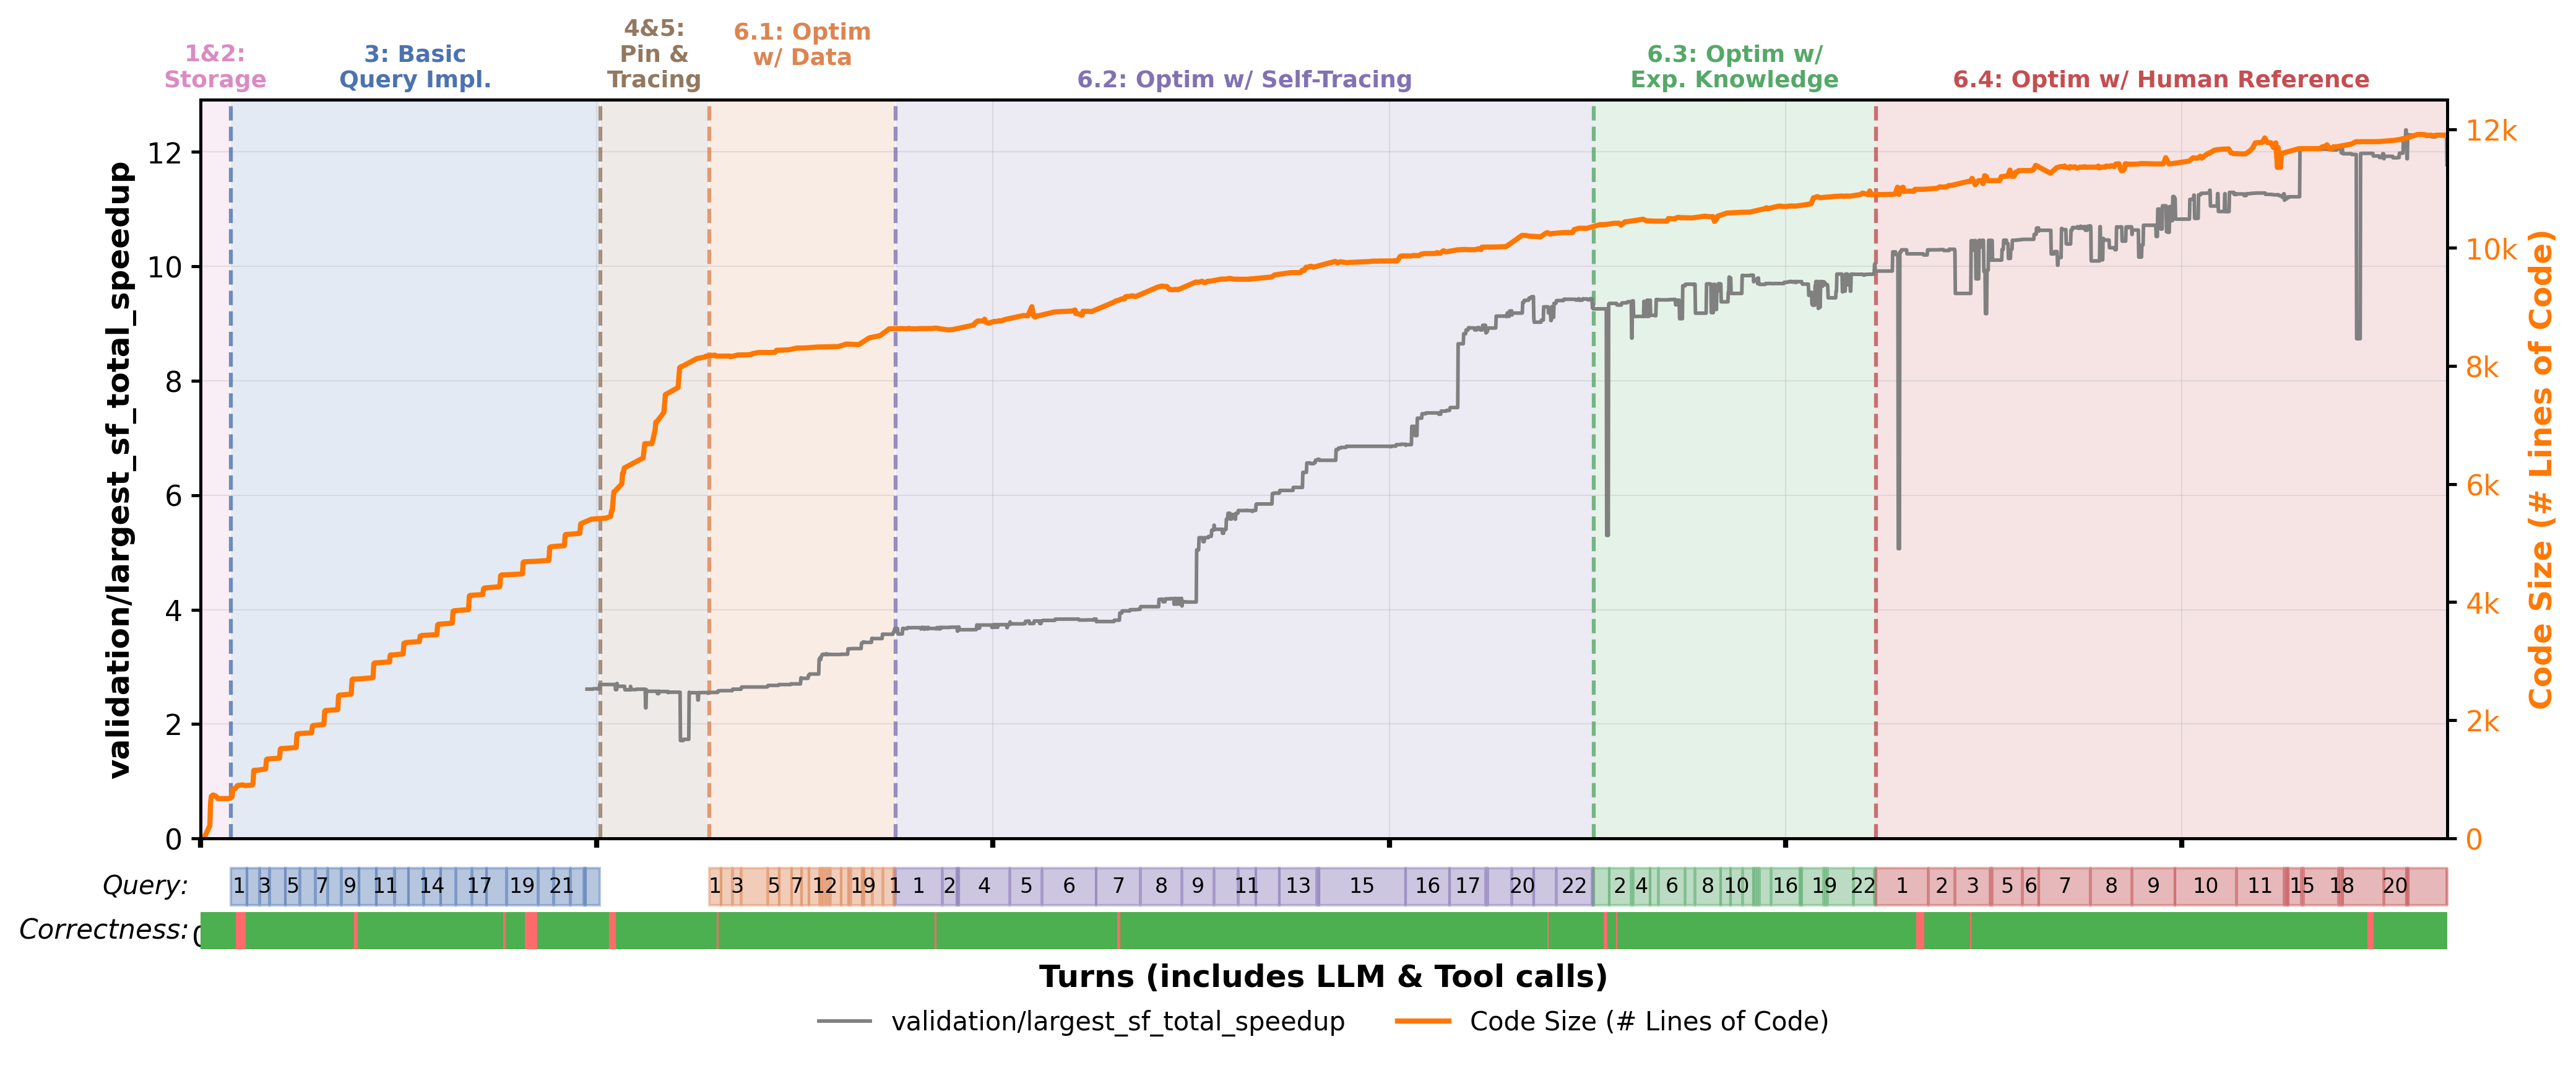

In [4]:
config = PlotConfig(
    left_axis_series=["validation/largest_sf_total_speedup"],
    right_axis_series=["code_size"],
)

fig, ax = engine.plot(config)

In [5]:
import re

blacklist = [
    "agent_name",
    "current_hash",
    "current_prompt",
    "shell/commands",
    "type",
]

filtered_keys = []
for key in summary.keys():
    if key.startswith("_"):
        continue

    if key in blacklist:
        continue

    if key.startswith("final"):
        continue

    if key.endswith("_data") or key.endswith("_plot_table"):
        continue

    if key.startswith("validation/total_"):
        continue

    if re.search(r"/query_\d+/", key):
        continue

    filtered_keys.append(key)
    print(key)

print(f"{len(summary.keys())} -> {len(filtered_keys)}")

filtered_keys.append("code_size")
filtered_keys.append("validation/largest_sf_total_speedup")

apply_patch/added_loc_count
apply_patch/create_count
apply_patch/delete_count
apply_patch/deleted_loc_count
apply_patch/update_count
cached_tokens
compaction/candidate_items
compaction/output_items
context_window_usage
cost_usd
current_loc
current_prompt_descriptor
input_tokens
output_tokens
prompt_idx
reasoning_tokens
shell/num_commands
tool/applypatchtool_count
tool/compaction_count
tool/handoff_count
tool/llmcall_count
tool/shellcommand_count
tool/validate_count
total/cached_tokens
total/cost_usd
total/input_tokens
total/output_tokens
total/reasoning_tokens
turn
validation/all_queries
validation/avg_speedup
validation/compile_error
validation/correct
validation/error
validation/external_call
validation/failed_query_id
validation/fasttest_optimize
validation/instantiations
validation/num_queries
validation/num_successful_queries
validation/query_ids_executed
validation/repetitions
validation/scale_factor
validation/sf1_all_queries_avg_speedup
validation/sf1_all_queries_total_speedup


In [6]:
from ipywidgets import interact, widgets


@interact(
    left_axis_series=widgets.SelectMultiple(
        options=sorted(filtered_keys),
        description="Left Axis Series",
        value=["input_tokens", "reasoning_tokens"],
    ),
    right_axis_series=widgets.SelectMultiple(
        options=sorted(filtered_keys),
        description="Right Axis Series",
        value=["code_size"],
    ),
    show_corrections=True,
    show_worked_on=True,
)
def update_plot(left_axis_series, right_axis_series, show_corrections, show_worked_on):
    plot_config = PlotConfig(
        left_axis_series=left_axis_series,
        right_axis_series=right_axis_series,
        highlight_correction_span=show_corrections,
        highlight_worked_on=show_worked_on,
    )
    engine.plot(plot_config)

interactive(children=(SelectMultiple(description='Left Axis Series', index=(13, 16), options=('apply_patch/add…